# Case Study - 1

**Agenda**
- Case Study: Exploring the Impact of Age, Price, and Sex on Shoe Size
  - Problem Overview
  - Modeling Approach
  - Key Hypothesis
  - Data Description
  - Importing Dataset
- Linear Regression: Predicting Shoe size from age
- Multiple Linear Regression: Including price as a Feature
- Polynomial Regression: Capturing Non-Linearity
- Comparative Analysis
- Conclusion

## Case Study: Exploring the Impact of Age, Price, and Sex on Shoe Size

### Problem Overview
  

In this case study, we aim to predict shoe size based on various features, with the primary focus on age. We will explore different regression models (Linear, Multiple Linear, and Polynomial Regression) to determine how well each model fits the data. Here are some key aspects to consider:

### Modeling Approach

* We apply three different regression techniques to analyze how each model handles the data and which one performs the best in terms of predicting shoe size:

   * Linear Regression: This assumes a linear relationship between age and shoe size. The model is simple, interpretable, and easy to implement, but may not capture non-linear patterns in the data.

   * Multiple Linear Regression: In addition to age, we incorporate the price(£) feature to explore whether the price of the shoe affects shoe size. This model allows for understanding the combined effects of multiple predictors.

   * Polynomial Regression: Here, we allow for a non-linear relationship between age and shoe size by transforming the age feature into polynomial terms (e.g., squared, cubed, etc.). This approach helps in capturing more complex relationships in the data, which may not be well represented by a straight line.

### Key Hypothesis

* Linear Regression Hypothesis: We hypothesize that shoe size increases linearly with age. For example, as children grow older, their shoe sizes typically increase.
* Multiple Linear Regression Hypothesis: In addition to age, the price of the shoe may have an effect on shoe size. For instance, more expensive shoes could be either larger or smaller based on trends in shoe pricing and manufacturing.
* Polynomial Regression Hypothesis: Shoe size may not increase at a constant rate with age. There may be periods of rapid growth (e.g., during childhood) followed by slower growth in older ages. The polynomial model will attempt to capture these non-linear growth patterns.

### Dataset Description

* The dataset includes information on individuals with the following features:
   * age: Age of the individual
   * shoe_size: The size of the individual's shoe
   * price(£): The price of the shoe in British pounds (£)
   * sex: The gender of the individual (though this feature is not used in the modeling)

[Download Dataset From Here](https://drive.google.com/file/d/1_lHkk4rqmHJD0Wn9VpoN4AOPBLamWQ3v/view?usp=sharing)

### Importing Dataset

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [ ]:
df = pd.read_csv('/content/exploring_dataset.csv')


In [ ]:
df = pd.DataFrame(df)

In [ ]:
df.head()

,age,shoe_size,price(£),sex
0,3,27,4,m
1,4,27,4,m
2,5,28,5,m
3,6,29,5,f
4,7,29,6,f


In [ ]:
df.describe()

,age,shoe_size,price(£)
count,1000.000000,1000.00000,1000.000000
mean,9.532000,30.70700,7.427000
std,3.484985,2.35174,3.361841
min,3.000000,27.00000,3.000000
25%,7.000000,29.00000,5.000000
50%,10.000000,31.00000,6.000000
75%,12.000000,32.00000,9.000000
max,16.000000,36.00000,15.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        1000 non-null   int64 
 1   shoe_size  1000 non-null   int64 
 2   price(£)   1000 non-null   int64 
 3   sex        1000 non-null   object
dtypes: int64(3), object(1)
memory usage: 31.4+ KB


### Visualizing the relationship between age and shoe size

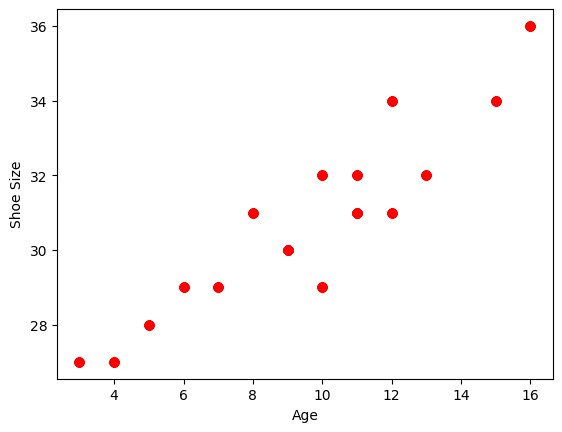

In [ ]:
plt.scatter(df.age, df.shoe_size, color="red")
plt.xlabel("Age")
plt.ylabel("Shoe Size")
plt.show()

## Linear Regression: Predicting Shoe Size from Age

### Initialize Linear Regression model

In [ ]:
from sklearn.linear_model import LinearRegression

linear_reg=LinearRegression()

# Age (independent variable)
x=df.iloc[:,[0]].values

# Shoe size (dependent variable)
y=df.shoe_size.values.reshape(-1,1)

# Fit the model
linear_reg.fit(x,y)

LinearRegression()

In [ ]:
x

array([[ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [ 9],
       [10],
       [11],
       [11],
       [12],
       [10],
       [11],
       [12],
       [13],
       [16],
       [15],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [ 9],
       [10],
       [11],
       [11],
       [12],
       [10],
       [11],
       [12],
       [13],
       [16],
       [15],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [ 9],
       [10],
       [11],
       [11],
       [12],
       [10],
       [11],
       [12],
       [13],
       [16],
       [15],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [ 9],
       [10],
       [11],
       [11],
       [12],
       [10],
       [11],
       [12],
       [13],
       [16],
       [15],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],

In [ ]:
b0=linear_reg.predict([[0]])
print("b0:",b0)

b0: [[24.7858227]]


In [ ]:
b0_=linear_reg.intercept_
print("b0_:",b0_) #intercept point

b0_: [24.7858227]


In [ ]:
b1=linear_reg.coef_
print("b1:",b1) #eğim

b1: [[0.62118939]]


In [ ]:
# Predictions
y_pred = linear_reg.predict(x)

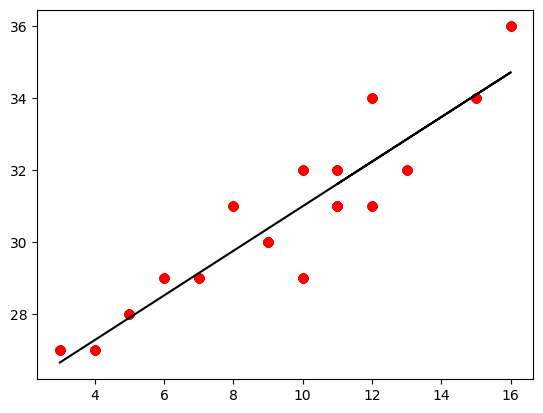

In [ ]:
plt.scatter(x, y, color="red")
plt.plot(x, y_pred, color="black")
plt.show()

### Cross-Validation

* You can use cross-validation to split the data multiple times and evaluate the model's performance more robustly.

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation with 5 folds
cv_scores = cross_val_score(linear_reg, x, y, cv=5, scoring='neg_mean_squared_error')

# Print the Mean Squared Error for each fold
print(f"Cross-Validation MSE Scores: {-cv_scores}")
print(f"Average MSE: {-cv_scores.mean()}")

Cross-Validation MSE Scores: [0.83787294 0.8381454  0.84474926 0.83831707 0.85760414]
Average MSE: 0.8433377605414032


Cross-validation gives you a better idea of model performance by reducing variance in test results.

### Residual Analysis

* You can check the residuals (differences between predicted and actual values) to see if there are any patterns in the errors, which would suggest issues with the model fit.

In [ ]:
# Calculating the residuals (actual - predicted)
residuals = y - y_pred

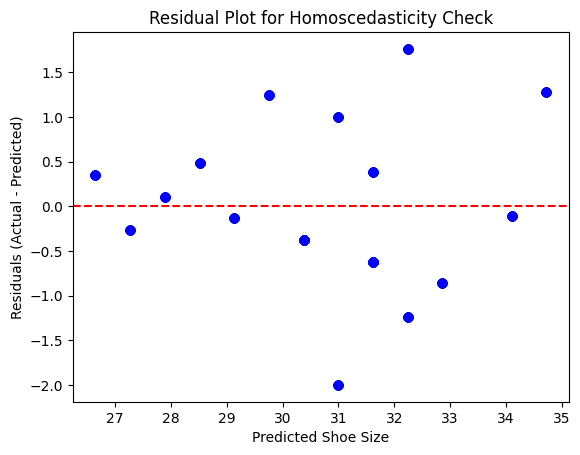

In [ ]:
# Plotting the residuals vs predicted values
plt.scatter(y_pred, residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot for Homoscedasticity Check')
plt.xlabel('Predicted Shoe Size')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

* Visual Interpretation:
   * In a residual plot, if the residuals are randomly scattered around 0 and do not form any clear pattern, the assumption of homoscedasticity holds.
   * If there is a pattern, such as the residuals forming a funnel shape (narrow at one end and wide at the other), the data may exhibit heteroscedasticity.

* Results:
   * Intercept (b0): [24.7858227]
   * Slope (b1): [[0.62118939]]
* This model suggests that for every additional year of age, the shoe size increases by approximately 0.58.

* Interpretation:
   * This linear model fits the data reasonably well, but may not capture all non-linear trends, as indicated by deviations in some parts of the dataset.

###  Normality of Errors

To perform the Normality of Errors in the context of our dataset, we will assess whether the residuals (errors) of the linear regression model follow a normal distribution. This is an important assumption in linear regression for inference purposes.

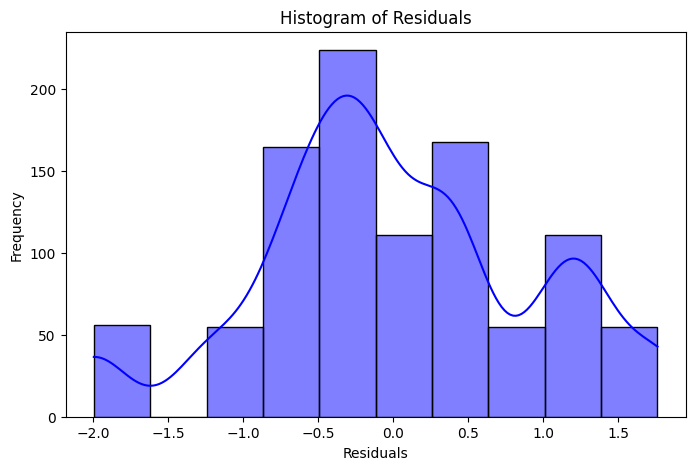

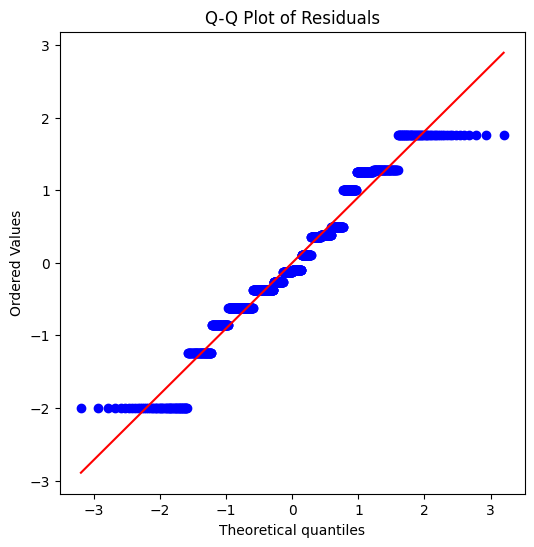

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

# Step 1: Prepare the data
X = df[['age']]  # We'll focus on 'age' as the independent variable for simplicity
y = df['shoe_size']

# Step 2: Fit a linear regression model
linear_reg = LinearRegression()
linear_reg.fit(X, y)

# Step 3: Predict shoe_size using the model
y_pred = linear_reg.predict(X)

# Step 4: Calculate residuals (actual - predicted)
residuals = y - y_pred

# Step 5: Plot a histogram of residuals
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True, color="blue", bins=10)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Step 6: Create a Q-Q plot to check normality
plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()



* Explanation:
   * Histogram of Residuals: A visual representation to check if the residuals are approximately normally distributed. If the residuals cluster around zero and form a bell-shaped curve, it indicates normality.
   * Q-Q Plot: This compares the distribution of residuals to a standard normal distribution. If the points lie along a straight line, it suggests that the residuals are normally distributed.

### Gradient Descent

* Steps for Gradient Descent:
   * Initialize Parameters: Start with random values for the model parameters (weights and bias).
   * Calculate Predictions: Compute the predicted values using the current parameters.
   * Compute Cost Function: The cost function (Mean Squared Error) measures the difference between the predicted and actual values.
   * Update Parameters: Using the gradient (partial derivatives of the cost function), update the weights and bias.
   * Repeat: Continue iterating until the parameters converge (i.e., when the change in cost is very small).

Bias (Intercept): -2.859354098326826e-09
Weight (Coefficient): 0.9205250786174167


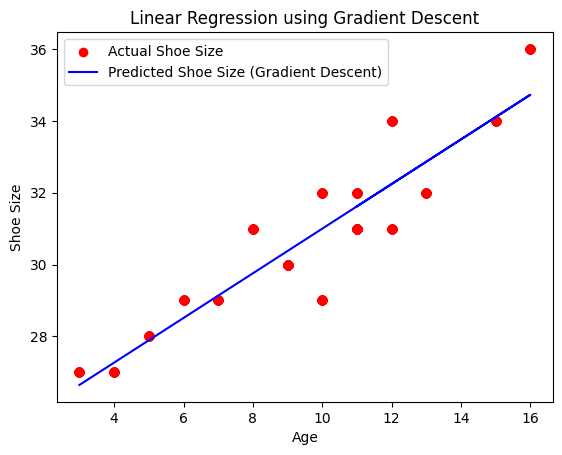

In [ ]:
import numpy as np
import pandas as pd

# Extract the 'age' as the independent variable and 'shoe_size' as the dependent variable
X = df['age'].values
y = df['shoe_size'].values

# Step 2: Normalize the data for better gradient descent performance
X_normalized = (X - np.mean(X)) / np.std(X)
y_normalized = (y - np.mean(y)) / np.std(y)

# Reshape X and y to be 2D arrays
X_normalized = X_normalized.reshape(-1, 1)
y_normalized = y_normalized.reshape(-1, 1)

# Step 3: Initialize parameters (weights and bias)
theta = np.random.randn(2, 1)  # Random initialization (theta[0] = bias, theta[1] = weight)

# Define Gradient Descent parameters
alpha = 0.01  # Learning rate
iterations = 1000  # Number of iterations

m = len(X_normalized)  # Number of examples

# Step 4: Add a column of ones to X_normalized to account for the bias term
X_b = np.c_[np.ones((m, 1)), X_normalized]

# Step 5: Gradient Descent Algorithm
for iteration in range(iterations):
    gradients = (2/m) * X_b.T.dot(X_b.dot(theta) - y_normalized)
    theta = theta - alpha * gradients

# Final model parameters (weights and bias)
bias = theta[0]
weight = theta[1]

print(f"Bias (Intercept): {bias[0]}")
print(f"Weight (Coefficient): {weight[0]}")

# Step 6: Make predictions using the learned model
y_pred = X_b.dot(theta)

# Step 7: Rescale predictions back to the original scale
y_pred_rescaled = y_pred * np.std(y) + np.mean(y)

# Step 8: Plot the result
import matplotlib.pyplot as plt

plt.scatter(X, y, color='red', label='Actual Shoe Size')
plt.plot(X, y_pred_rescaled, color='blue', label='Predicted Shoe Size (Gradient Descent)')
plt.xlabel('Age')
plt.ylabel('Shoe Size')
plt.title('Linear Regression using Gradient Descent')
plt.legend()
plt.show()


##  Multiple Linear Regression: Including Price as a Feature

Extend the model to include price(£) as an additional feature to predict shoe size.

In [ ]:
df.head()

,age,shoe_size,price(£),sex
0,3,27,4,m
1,4,27,4,m
2,5,28,5,m
3,6,29,5,f
4,7,29,6,f


In [ ]:
x = df.iloc[:, [0, 2]].values  # Age and Price as independent variables
x

array([[ 3,  4],
       [ 4,  4],
       [ 5,  5],
       ...,
       [ 9,  7],
       [10,  8],
       [11,  5]])

In [ ]:
y = df.shoe_size.values.reshape(-1, 1)
y

array([[27],
       [27],
       [28],
       [29],
       [29],
       [31],
       [30],
       [30],
       [29],
       [32],
       [31],
       [34],
       [32],
       [31],
       [31],
       [32],
       [36],
       [34],
       [27],
       [27],
       [28],
       [29],
       [29],
       [31],
       [30],
       [30],
       [29],
       [32],
       [31],
       [34],
       [32],
       [31],
       [31],
       [32],
       [36],
       [34],
       [27],
       [27],
       [28],
       [29],
       [29],
       [31],
       [30],
       [30],
       [29],
       [32],
       [31],
       [34],
       [32],
       [31],
       [31],
       [32],
       [36],
       [34],
       [27],
       [27],
       [28],
       [29],
       [29],
       [31],
       [30],
       [30],
       [29],
       [32],
       [31],
       [34],
       [32],
       [31],
       [31],
       [32],
       [36],
       [34],
       [27],
       [27],
       [28],
       [29],
       [29],

### Handling Categorical Variables


* In the dataset, sex is a categorical variable (m, f). You can include this in your regression model by converting it into numerical values using One-Hot Encoding or Label Encoding.


In [ ]:
# Convert categorical 'sex' into dummy variables
df_encoded = pd.get_dummies(df, columns=['sex'], drop_first=True)

# Use the encoded dataset for multiple regression
X_multi = df_encoded[['age', 'price(£)', 'sex_m']]
y = df_encoded['shoe_size']

# Fit and evaluate the multiple linear regression model
multi_reg = LinearRegression()
multi_reg.fit(X_multi, y)

print("Coefficients:", multi_reg.coef_)
print("Intercept:", multi_reg.intercept_)

Coefficients: [ 0.67083133 -0.06071165  0.34068881]
Intercept: 24.574118271605258


This will include sex_m (1 for male, 0 for female) as a feature in the model.



### Initialize Multiple Linear Regression Model

In [ ]:
# Initialize and fit the model
multiple_linear_regression = LinearRegression()
multiple_linear_regression.fit(x, y)


LinearRegression()

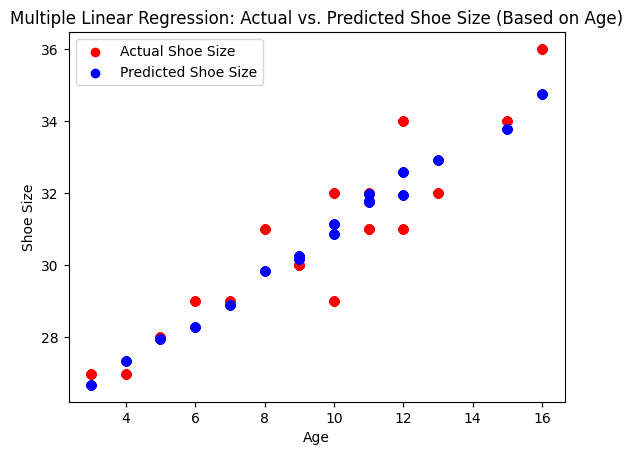

In [ ]:
# Predict the shoe size using the model
y_pred = multi_reg.predict(X_multi)

# Plot predicted vs. actual shoe size (based on 'age')
plt.scatter(df_encoded['age'], df_encoded['shoe_size'], color='red', label='Actual Shoe Size')
plt.scatter(df_encoded['age'], y_pred, color='blue', label='Predicted Shoe Size')

# Set plot labels and title
plt.xlabel('Age')
plt.ylabel('Shoe Size')
plt.title('Multiple Linear Regression: Actual vs. Predicted Shoe Size (Based on Age)')
plt.legend()

# Display the plot
plt.show()


### Check for Multicollinearity

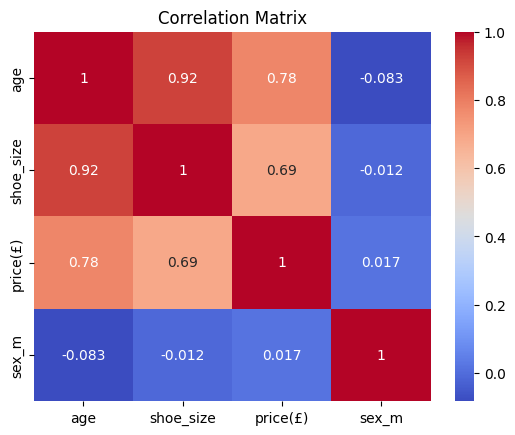

   Variable        VIF
0       age  15.093942
1  price(£)  15.192374
2     sex_m   1.902656


In [ ]:
import pandas as pd
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

# Convert columns to numeric and drop any rows with NaN values
X_multi_vif = X_multi_vif.apply(pd.to_numeric, errors='coerce').dropna()

# Plot the correlation matrix
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Check for multicollinearity using Variance Inflation Factor (VIF)
vif = pd.DataFrame()
vif["Variable"] = X_multi_vif.columns

# Convert X_multi_vif to float
X_multi_vif = X_multi_vif.astype(float)
vif["VIF"] = [variance_inflation_factor(X_multi_vif.values, i) for i in range(X_multi_vif.shape[1])]

print(vif)


###  Regularization (Ridge and Lasso Regression)

* Regularization techniques like Ridge and Lasso regression are useful when dealing with high-dimensional data or when you want to penalize large coefficients to prevent overfitting.

In [ ]:
# Ridge Regression (L2 Regularization)
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_multi, y)

print("Ridge Coefficients:", ridge_reg.coef_)


Ridge Coefficients: [ 0.67062784 -0.06053821  0.33917626]


In [ ]:
# Lasso Regression (L1 Regularization)
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_multi, y)

print("Lasso Coefficients:", lasso_reg.coef_)


Lasso Coefficients: [ 0.62100154 -0.01076953  0.        ]


## Polynomial Regression: Capturing Non-Linearity

Fit a polynomial regression model to account for non-linearity in the relationship between age and shoe size.

In [ ]:
df.head()

,age,shoe_size,price(£),sex
0,3,27,4,m
1,4,27,4,m
2,5,28,5,m
3,6,29,5,f
4,7,29,6,f


### Initialize Polynomial regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

polynomial_reg = PolynomialFeatures(degree=range(2,10))

In [ ]:
x=df.iloc[:,[0]].values
x

array([[ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [ 9],
       [10],
       [11],
       [11],
       [12],
       [10],
       [11],
       [12],
       [13],
       [16],
       [15],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [ 9],
       [10],
       [11],
       [11],
       [12],
       [10],
       [11],
       [12],
       [13],
       [16],
       [15],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [ 9],
       [10],
       [11],
       [11],
       [12],
       [10],
       [11],
       [12],
       [13],
       [16],
       [15],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [ 9],
       [10],
       [11],
       [11],
       [12],
       [10],
       [11],
       [12],
       [13],
       [16],
       [15],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],

In [ ]:
y=df.shoe_size.values.reshape(-1,1)
y

array([[27],
       [27],
       [28],
       [29],
       [29],
       [31],
       [30],
       [30],
       [29],
       [32],
       [31],
       [34],
       [32],
       [31],
       [31],
       [32],
       [36],
       [34],
       [27],
       [27],
       [28],
       [29],
       [29],
       [31],
       [30],
       [30],
       [29],
       [32],
       [31],
       [34],
       [32],
       [31],
       [31],
       [32],
       [36],
       [34],
       [27],
       [27],
       [28],
       [29],
       [29],
       [31],
       [30],
       [30],
       [29],
       [32],
       [31],
       [34],
       [32],
       [31],
       [31],
       [32],
       [36],
       [34],
       [27],
       [27],
       [28],
       [29],
       [29],
       [31],
       [30],
       [30],
       [29],
       [32],
       [31],
       [34],
       [32],
       [31],
       [31],
       [32],
       [36],
       [34],
       [27],
       [27],
       [28],
       [29],
       [29],

In [ ]:
# Create polynomial features with degree 2 to 10.
polynomial_reg = PolynomialFeatures(degree=range(2,10))

In [ ]:

linear_3=LinearRegression()
linear_3.fit(x_poly,y)

LinearRegression()

In [ ]:
# Create a range of x values for smoother plotting
x_range = np.linspace(min(x), max(x), 100).reshape(-1, 1)  # Create 100 points between min and max of x


In [ ]:
# Predict using the polynomial regression model
y_head2=linear_3.predict(x_range_poly)

### Plotting the polynomial curve

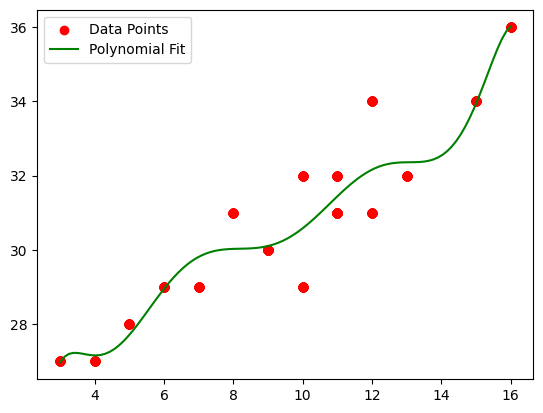

In [ ]:
plt.scatter(x, y, color="red", label="Data Points")  # Scatter plot of original data
plt.plot(x_range, y_head2, color="green", label="Polynomial Fit")  # Polynomial regression curve
plt.legend()
plt.show()

* **Plotting each polynomial degree from 2 to 9 using line plot.**

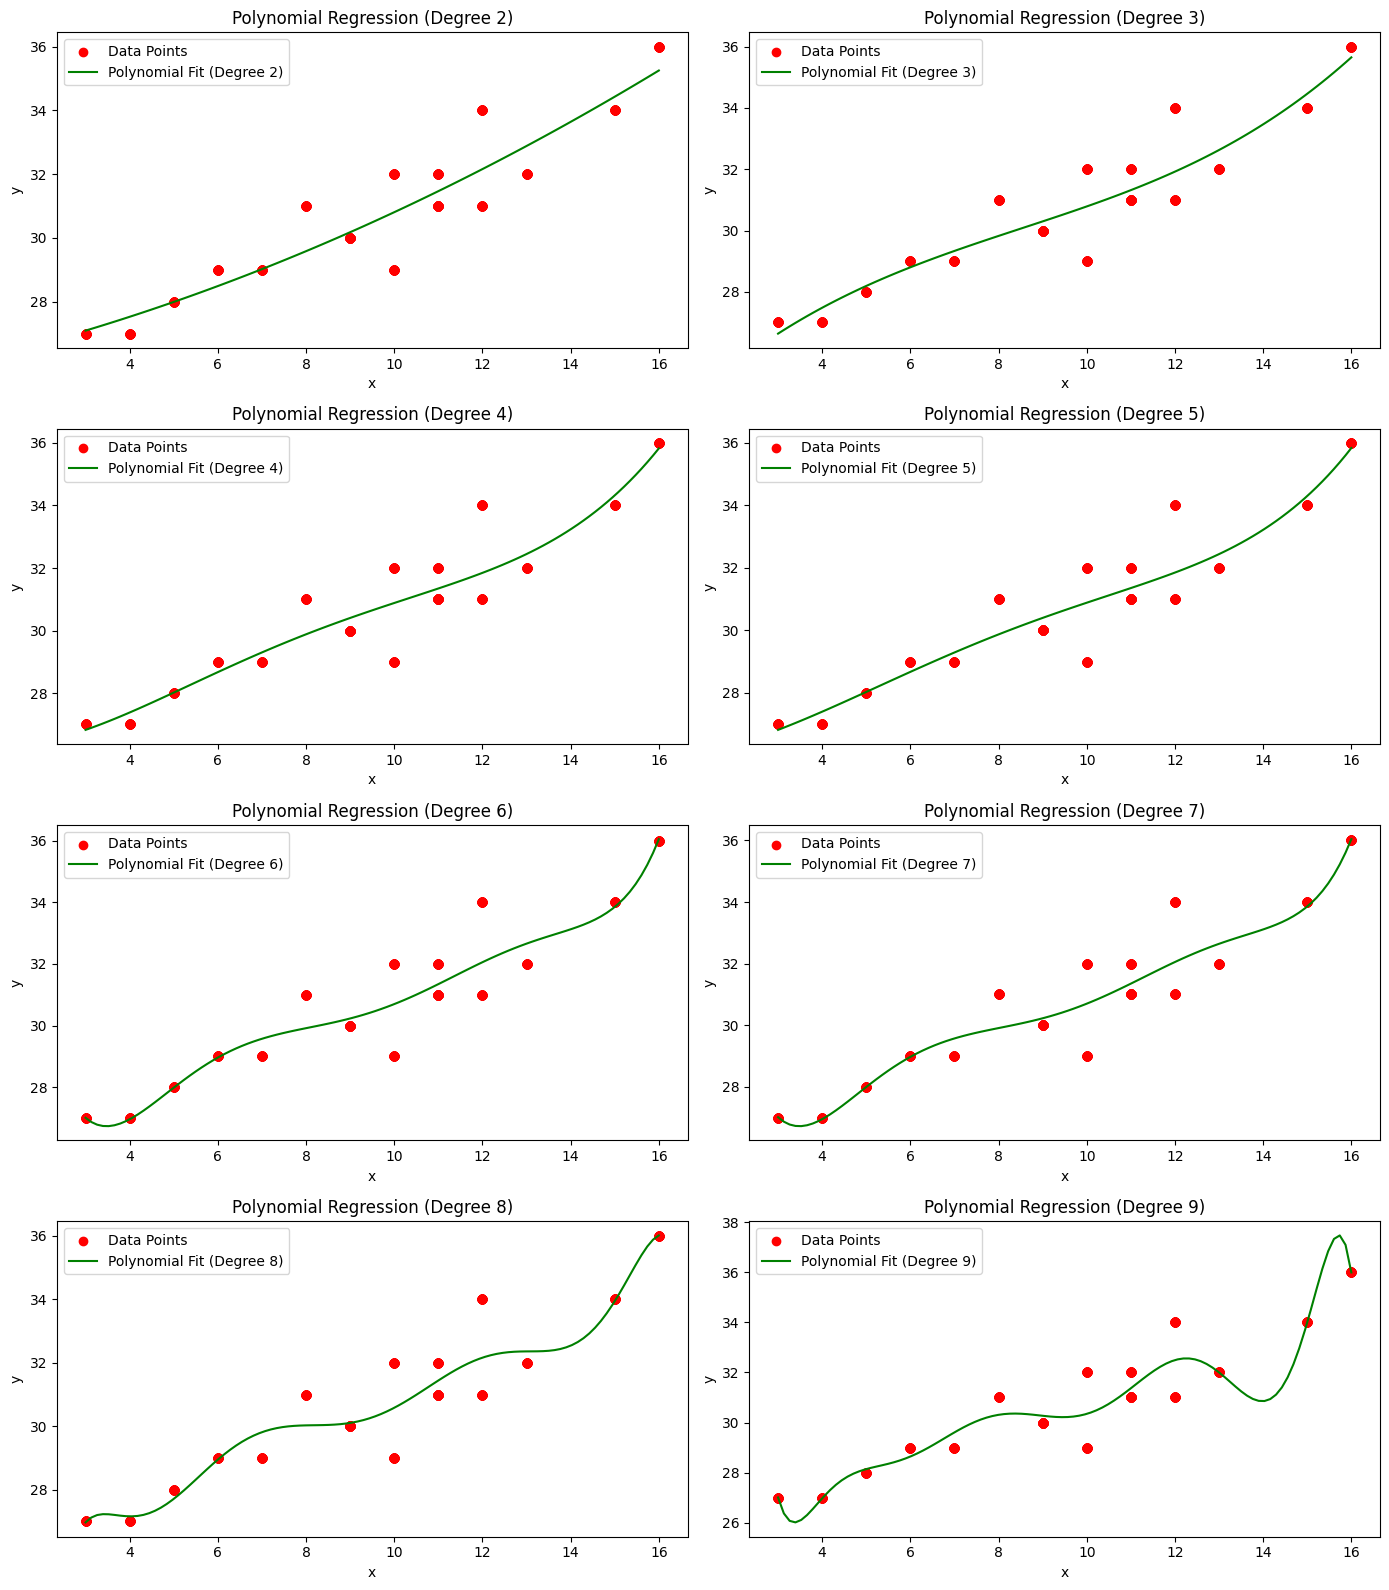

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Assuming x and y are your feature and target arrays

# Create a figure and axes for the subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))  # 4 rows, 2 columns for 8 plots

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Loop through each degree from 2 to 9 and plot separately
for i, degree in enumerate(range(2, 10)):
    # Create polynomial features for the current degree
    polynomial_reg = PolynomialFeatures(degree=degree)
    x_poly = polynomial_reg.fit_transform(x.reshape(-1, 1))  # Reshape x if it's 1D

    # Fit the polynomial regression model
    linear_model = LinearRegression()
    linear_model.fit(x_poly, y)

    # Create a range of x values for smoother plotting
    x_range = np.linspace(min(x), max(x), 100).reshape(-1, 1)
    x_range_poly = polynomial_reg.transform(x_range)

    # Predict using the polynomial model
    y_range_pred = linear_model.predict(x_range_poly)

    # Plot the polynomial curve for the current degree on its own subplot
    axes[i].scatter(x, y, color="red", label="Data Points")  # Plot original data points
    axes[i].plot(x_range, y_range_pred, color="green", label=f'Polynomial Fit (Degree {degree})')  # Plot polynomial curve
    axes[i].set_title(f"Polynomial Regression (Degree {degree})")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")
    axes[i].legend()

# Adjust the layout to prevent overlap of subplots
plt.tight_layout()
plt.show()


* Low Degree (e.g., Degree 1 or 2):

   * Characteristics: These models provide a simple fit that captures only the most general trends.
   * Pros: Low bias, likely to generalize well to unseen data.
   * Cons: May underfit the data if the relationship is more complex (high bias).
* Moderate Degree (e.g., Degree 3 to 5):

   * Characteristics: These models can capture more intricate relationships while avoiding excessive complexity.
   * Pros: Better at fitting the data than low-degree polynomials and still have a reasonable chance of generalizing well.
   * Cons: Risk of slight overfitting, but manageable with proper cross-validation.
* High Degree (e.g., Degree 6 to 8):

   * Characteristics: These models can fit almost all variations in the training data, including noise.
   * Pros: Very low training error, capturing complex patterns.
   * Cons: High risk of overfitting, leading to poor generalization (high test error).

### Interaction Terms

* In some cases, interaction terms between features can provide additional insights. For example, the interaction between age and price might have an impact on shoe_size.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Add interaction terms between age and price
interaction = PolynomialFeatures(degree=(2,10), interaction_only=True, include_bias=False)
X_interaction = interaction.fit_transform(X_multi)

# Fit the model on interaction features
interaction_reg = LinearRegression()
interaction_reg.fit(X_interaction, y)

print("Coefficients with interaction terms:", interaction_reg.coef_)

Coefficients with interaction terms: [[ 0.02263063  0.51429499 -1.04509733  0.03686265]]


### Bias-Variance Tradeoff in Polynomial Regression

* The dataset contains 18 observations of age, shoe size, price (£), and sex. We'll focus on modeling the relationship between age (independent variable) and shoe size (dependent variable) using polynomial regression of degree 8.

Training Error (MSE) for degree (2, 10): 0.5804394984344875
Test Error (MSE) for degree (2, 10): 0.6518663143001572


<ipython-input-269-9d18c25d6e7c>:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)  # For smoother curve


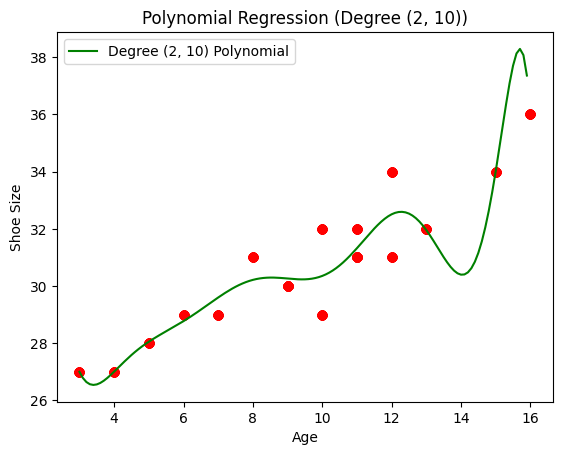

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Creating the updated dataset
df = pd.read_csv('/content/exploring_dataset.csv')
df = pd.DataFrame(df)

# Defining features (age) and target (shoe_size)
X = df[['age']].values
y = df['shoe_size'].values

# Splitting data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Creating polynomial features for degree 2 to 10
degree = (2,10)
poly_features = PolynomialFeatures(degree=degree)
X_poly_train = poly_features.fit_transform(X_train)
X_poly_test = poly_features.transform(X_test)

# Fitting polynomial regression
poly_reg = LinearRegression()
poly_reg.fit(X_poly_train, y_train)

# Predictions
y_train_pred = poly_reg.predict(X_poly_train)
y_test_pred = poly_reg.predict(X_poly_test)

# Calculating Mean Squared Error for both training and test sets
train_error = mean_squared_error(y_train, y_train_pred)
test_error = mean_squared_error(y_test, y_test_pred)

print(f"Training Error (MSE) for degree {degree}: {train_error}")
print(f"Test Error (MSE) for degree {degree}: {test_error}")

# Visualizing the results
plt.scatter(X, y, color='red')
X_grid = np.arange(min(X), max(X), 0.1)  # For smoother curve
X_grid = X_grid.reshape((len(X_grid), 1))
X_poly_grid = poly_features.transform(X_grid)
y_poly_pred = poly_reg.predict(X_poly_grid)
plt.plot(X_grid, y_poly_pred, color='green', label=f'Degree {degree} Polynomial')
plt.xlabel("Age")
plt.ylabel("Shoe Size")
plt.title(f'Polynomial Regression (Degree {degree})')
plt.legend()
plt.show()


This demonstrates the bias-variance tradeoff, where increasing model complexity reduces bias but increases variance.

## Comparative Analysis: Linear vs Polynomial Regression

* Model Complexity:

   * Linear Regression is simple and interpretable, but it assumes a straight-line relationship between variables.
   * Polynomial Regression can model more complex, non-linear relationships, but it may overfit if the degree is too high.
* Fitting to Data:

   * In this dataset, polynomial regression fits the data better because it captures non-linear patterns in shoe size progression as age increases.
   * Linear regression provides a rough estimate but is not flexible enough for capturing these subtle patterns.
* Model Interpretability:

   * Linear regression is easy to interpret with only two parameters (slope and intercept).
   * Polynomial regression, especially with higher degrees, becomes harder to interpret as it introduces many more terms in the equation.

## Conclusion

### Linear Regression

* In the context of this dataset, a simple linear regression was used to model the relationship between age and shoe size. The results showed a fairly straightforward linear trend between these variables, as expected (shoe size generally increases with age).

   * Strengths: Linear regression provides a simple, interpretable model with a single independent variable. It's easy to understand and visualize.
   * Limitations: In this case, the linear model fails to capture more complex relationships between the variables. For example, shoe size may increase non-linearly with age at certain points in the dataset. The model may also ignore other influential variables, such as price (£) and sex.

###Multiple Linear Regression

* Multiple linear regression incorporated additional features, such as price (£) and age, to predict shoe size. The model produced better results than simple linear regression, as it captured the effects of multiple variables simultaneously.

   * Strengths: This model was more comprehensive by considering the combined effects of age and price (£), resulting in improved accuracy. It showed how multiple factors contribute to shoe size variation.
   * Limitations: Despite the improvement, multiple linear regression assumes that the relationship between predictors and the target variable is linear. This assumption may not always hold true for real-world data, as relationships between variables can often be more complex and non-linear.

### Polynomial Regression

* Polynomial regression was applied with a degree 8 polynomial to capture more complex, non-linear relationships between age and shoe size. While the training error was very low, the model exhibited signs of overfitting.

   * Strengths: Polynomial regression can capture more complex relationships that a linear model might miss. In this case, it fits the training data very well (low bias).
   * Limitations: The high degree polynomial (degree 8) overfit the data, resulting in poor generalization to unseen data (high variance). The model was too flexible, capturing random noise rather than the true underlying trend, leading to a high test error.